In [22]:
import pandas as pd
import numpy as np

np.random.seed(42)
raw_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'] * 3
segments = ['Retail', 'Corporate', 'SME'] * 12

revenue_data = [45, 52, np.nan, 60, 65, 58, 72, 78, 70, 85, 92, 105] * 3
expenses_data = [30, 32, 35, 38, np.nan, 42, 45, 47, 46, 50, 52, 55] * 3

df_raw = pd.DataFrame({
    'Transaction_ID': [1001 + i for i in range(36)],
    'Month': raw_months,
    'Segment': segments,
    'Revenue_Lakhs': revenue_data,
    'Expenses_Lakhs': expenses_data,
    'Status': ['SUCCESS', 'success', 'FAILED', 'Success', 'PENDING', 'success', 'SUCCESS', 'failed', 'SUCCESS', 'SUCCESS', 'SUCCESS', 'SUCCESS'] * 3
})
df_raw

,Transaction_ID,Month,Segment,Revenue_Lakhs,Expenses_Lakhs,Status
0,1001,Jan,Retail,45.0,30.0,SUCCESS
1,1002,Feb,Corporate,52.0,32.0,success
2,1003,Mar,SME,NaN,35.0,FAILED
3,1004,Apr,Retail,60.0,38.0,Success
4,1005,May,Corporate,65.0,NaN,PENDING
5,1006,Jun,SME,58.0,42.0,success
6,1007,Jul,Retail,72.0,45.0,SUCCESS
7,1008,Aug,Corporate,78.0,47.0,failed
8,1009,Sep,SME,70.0,46.0,SUCCESS
9,1010,Oct,Retail,85.0,50.0,SUCCESS


In [23]:
df_raw.info

<bound method DataFrame.info of     Transaction_ID Month    Segment  Revenue_Lakhs  Expenses_Lakhs   Status
0             1001   Jan     Retail           45.0            30.0  SUCCESS
1             1002   Feb  Corporate           52.0            32.0  success
2             1003   Mar        SME            NaN            35.0   FAILED
3             1004   Apr     Retail           60.0            38.0  Success
4             1005   May  Corporate           65.0             NaN  PENDING
5             1006   Jun        SME           58.0            42.0  success
6             1007   Jul     Retail           72.0            45.0  SUCCESS
7             1008   Aug  Corporate           78.0            47.0   failed
8             1009   Sep        SME           70.0            46.0  SUCCESS
9             1010   Oct     Retail           85.0            50.0  SUCCESS
10            1011   Nov  Corporate           92.0            52.0  SUCCESS
11            1012   Dec        SME          105.0      

In [7]:
df_raw.columns
df_raw.isna().sum()

Transaction_ID    0
Month             0
Segment           0
Revenue_Lakhs     3
Expenses_Lakhs    3
Status            0
dtype: int64

In [8]:
mean_rev = df_raw['Revenue_Lakhs'].mean() 
df_raw['Revenue_Lakhs'] = df_raw['Revenue_Lakhs'].fillna(mean_rev) 

mean_exp = df_raw['Expenses_Lakhs'].mean() 
df_raw['Expenses_Lakhs'] = df_raw['Expenses_Lakhs'].fillna(mean_exp)

df_raw.isna().sum()


Transaction_ID    0
Month             0
Segment           0
Revenue_Lakhs     0
Expenses_Lakhs    0
Status            0
dtype: int64

In [9]:
df_raw['Status'] = df_raw['Status'].str.upper()
df_raw['Status'].unique()

array(['SUCCESS', 'FAILED', 'PENDING'], dtype=object)

In [10]:
df_raw = df_raw.drop_duplicates()
df_raw.shape

(36, 6)

In [21]:
display(df_raw.head(5))
display(df_raw.tail(5))

,Transaction_ID,Month,Segment,Revenue_Lakhs,Expenses_Lakhs,Status
0,1001,Jan,Retail,45.000000,30.000000,SUCCESS
1,1002,Feb,Corporate,52.000000,32.000000,SUCCESS
2,1003,Mar,SME,71.090909,35.000000,FAILED
3,1004,Apr,Retail,60.000000,38.000000,SUCCESS
4,1005,May,Corporate,65.000000,42.909091,PENDING


,Transaction_ID,Month,Segment,Revenue_Lakhs,Expenses_Lakhs,Status
31,1032,Aug,Corporate,78.0,47.0,FAILED
32,1033,Sep,SME,70.0,46.0,SUCCESS
33,1034,Oct,Retail,85.0,50.0,SUCCESS
34,1035,Nov,Corporate,92.0,52.0,SUCCESS
35,1036,Dec,SME,105.0,55.0,SUCCESS


In [26]:
outliers = df_raw[(df_raw['Revenue_Lakhs'] > 1000) | (df_raw['Revenue_Lakhs'] < 0)]
display(outliers)

median_rev = df_raw['Revenue_Lakhs'].median()
df_raw.loc[df_raw['Revenue_Lakhs'] > 1000, 'Revenue_Lakhs'] = median_rev
df_raw.loc[df_raw['Expenses_Lakhs'] < 0, 'Expenses_Lakhs'] = df_raw['Expenses_Lakhs'].median()

df_raw.describe()

,Transaction_ID,Month,Segment,Revenue_Lakhs,Expenses_Lakhs,Status


,Transaction_ID,Revenue_Lakhs,Expenses_Lakhs
count,36.000000,33.000000,33.000000
mean,1018.500000,71.090909,42.909091
std,10.535654,17.339196,8.001420
min,1001.000000,45.000000,30.000000
25%,1009.750000,58.000000,35.000000
50%,1018.500000,70.000000,45.000000
75%,1027.250000,85.000000,50.000000
max,1036.000000,105.000000,55.000000


In [27]:
df_raw['Revenue_Lakhs'] = df_raw['Revenue_Lakhs'].fillna(df_raw['Revenue_Lakhs'].median())
df_raw['Expenses_Lakhs'] = df_raw['Expenses_Lakhs'].fillna(df_raw['Expenses_Lakhs'].median())
df_raw.describe()

,Transaction_ID,Revenue_Lakhs,Expenses_Lakhs
count,36.000000,36.000000,36.000000
mean,1018.500000,71.000000,43.083333
std,10.535654,16.582262,7.673237
min,1001.000000,45.000000,30.000000
25%,1009.750000,59.500000,37.250000
50%,1018.500000,70.000000,45.000000
75%,1027.250000,79.750000,47.750000
max,1036.000000,105.000000,55.000000


In [32]:
df_melted = pd.melt(df_raw,id_vars=['Transaction_ID','Month','Segment','Status'],
                    value_vars=['Revenue_Lakhs','Expenses_Lakhs'],var_name='Financial_Metric',value_name='Amount'
                   )
                   

display(df_melted.head(10))

,Transaction_ID,Month,Segment,Status,Financial_Metric,Amount
0,1001,Jan,Retail,SUCCESS,Revenue_Lakhs,45.0
1,1002,Feb,Corporate,success,Revenue_Lakhs,52.0
2,1003,Mar,SME,FAILED,Revenue_Lakhs,70.0
3,1004,Apr,Retail,Success,Revenue_Lakhs,60.0
4,1005,May,Corporate,PENDING,Revenue_Lakhs,65.0
5,1006,Jun,SME,success,Revenue_Lakhs,58.0
6,1007,Jul,Retail,SUCCESS,Revenue_Lakhs,72.0
7,1008,Aug,Corporate,failed,Revenue_Lakhs,78.0
8,1009,Sep,SME,SUCCESS,Revenue_Lakhs,70.0
9,1010,Oct,Retail,SUCCESS,Revenue_Lakhs,85.0


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

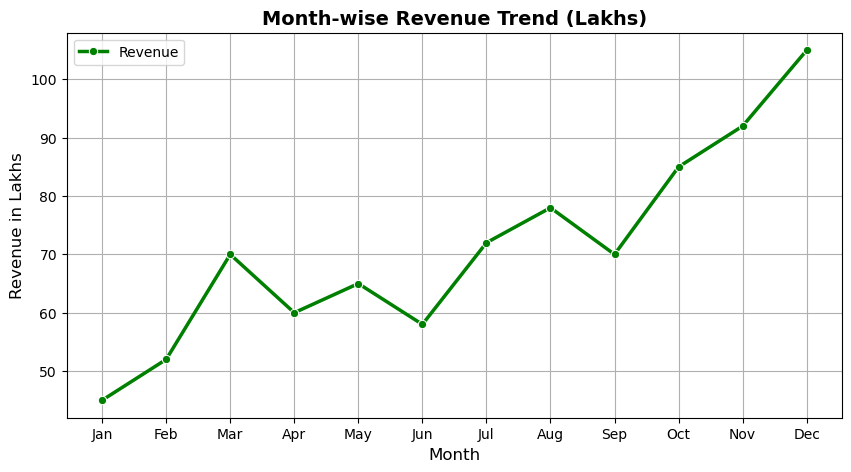

In [41]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df_raw, x='Month', y='Revenue_Lakhs',marker='o',color='green',linewidth=2.5,label='Revenue')
plt.title('Month-wise Revenue Trend (Lakhs)',fontsize=14,fontweight='bold')
plt.xlabel('Month',fontsize=12)
plt.ylabel('Revenue in Lakhs',fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

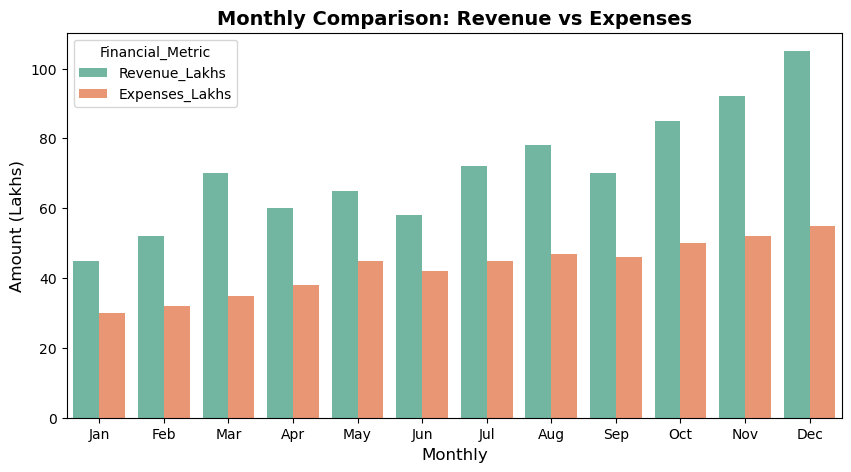

In [48]:
plt.figure(figsize=(10,5))
sns.barplot(data=df_melted,x='Month', y='Amount',hue='Financial_Metric',palette='Set2')

plt.title('Monthly Comparison: Revenue vs Expenses',fontsize=14,fontweight='bold')
plt.xlabel('Monthly',fontsize=12)
plt.ylabel('Amount (Lakhs)',fontsize=12)
plt.legend(title='Financial_Metric')
plt.show()